# Determinants of Salary: A Multiple Linear Regression Analysis of Job Market Data

### This project applies Multiple Linear Regression to predict salaries based on job-related factors such as experience, education, and industry. The goal is to understand which variables significantly influence salary outcomes and to build a model with strong predictive performance. This analysis combines statistical reasoning with machine learning techniques to extract actionable insights from structured job data.

In [1]:
#!pip install category_encoders
%matplotlib inline
import warnings
import streamlit as st
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
remote_map = {
    "Yes": "Remote",
    "No": "Onsite",
    "Hybrid": "Hybrid"
}

df["remote_work"] = df["remote_work"].map(remote_map)

In [4]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,Onsite,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,Onsite,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Remote,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Remote,0,165069


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


# Exploratory Data Analysis (EDA)

In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


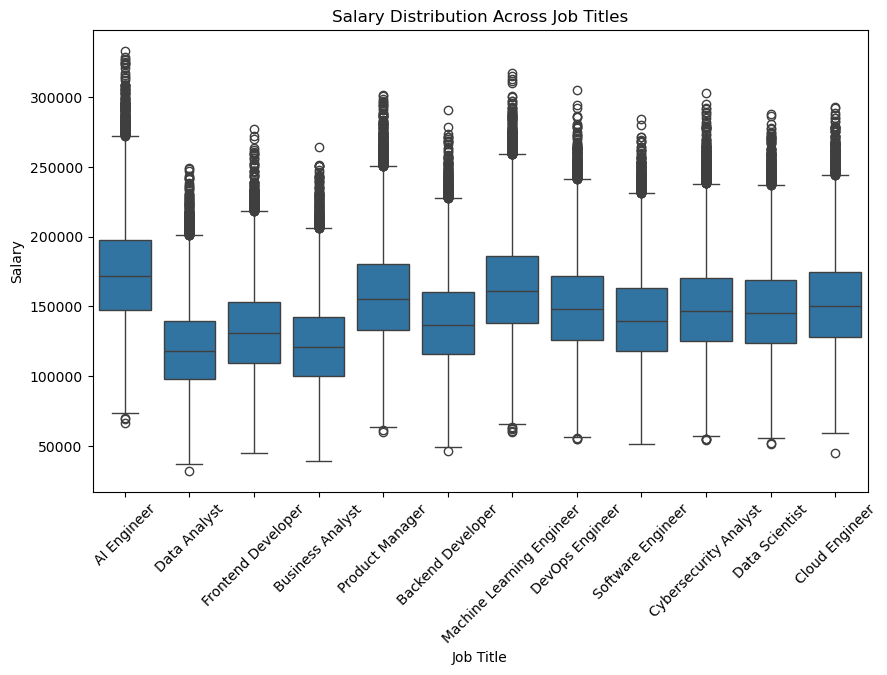

In [7]:
plt.figure(figsize=(10,6))

sns.boxplot(x='job_title', y='salary', data=df)

plt.title('Salary Distribution Across Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Salary')

plt.xticks(rotation=45)
plt.show()

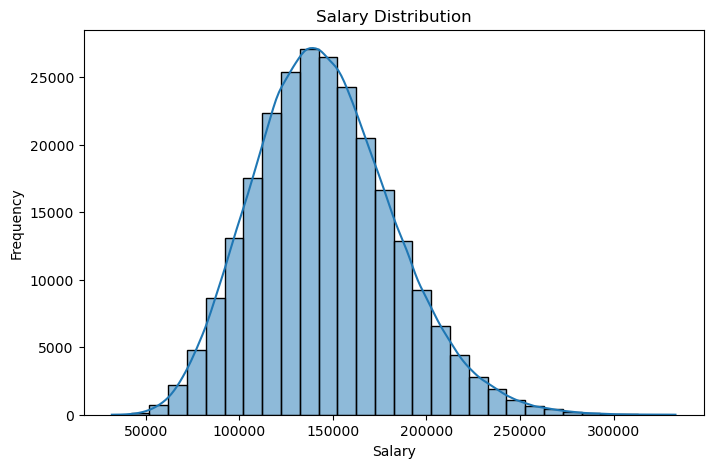

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['salary'], bins=30, kde=True)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')

plt.show()

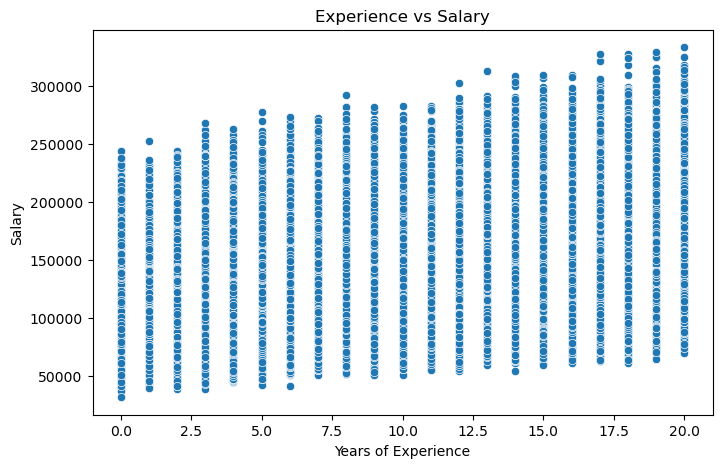

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='experience_years', y='salary', data=df)

plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

plt.show()

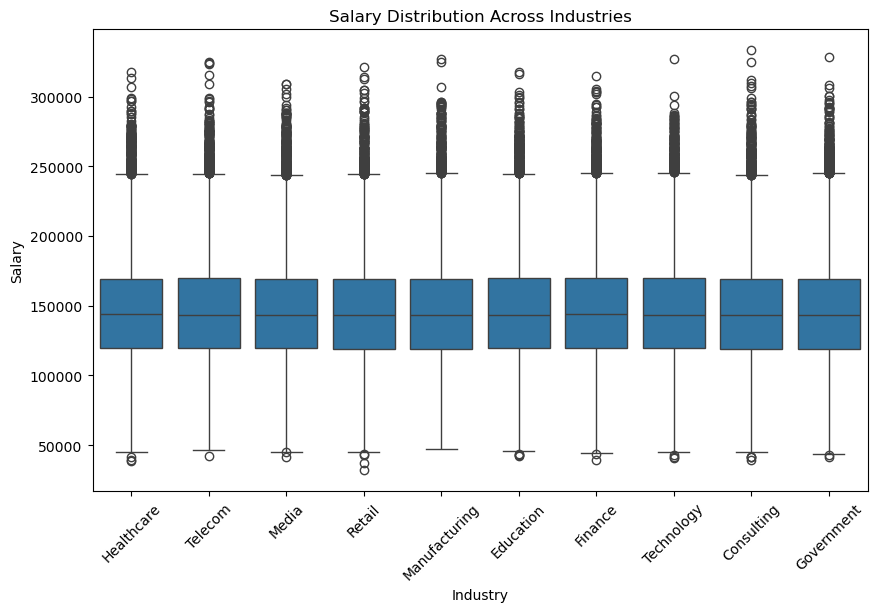

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(x='industry', y='salary', data=df)

plt.title('Salary Distribution Across Industries')
plt.xlabel('Industry')
plt.ylabel('Salary')

plt.xticks(rotation=45)
plt.show()

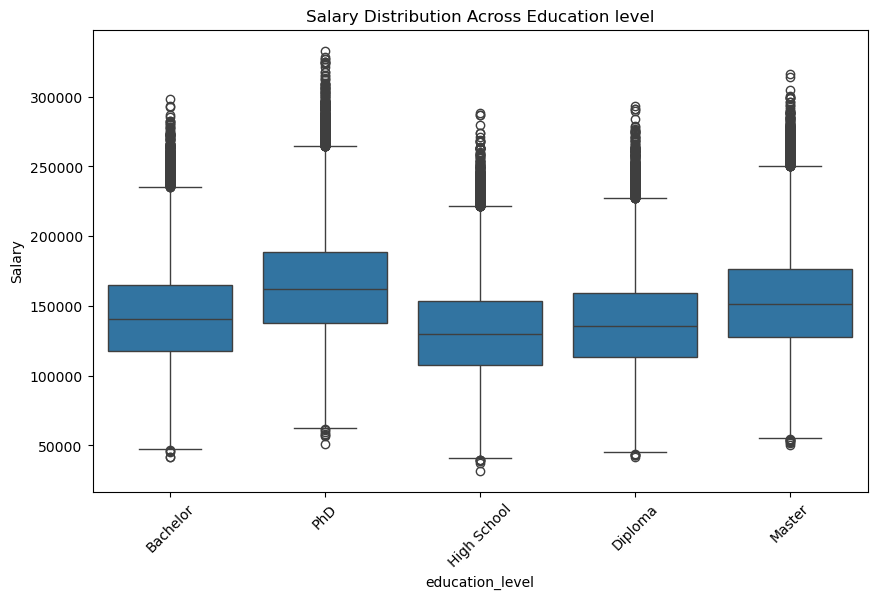

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(x='education_level', y='salary', data=df)

plt.title('Salary Distribution Across Education level')
plt.xlabel('education_level')
plt.ylabel('Salary')

plt.xticks(rotation=45)
plt.show()

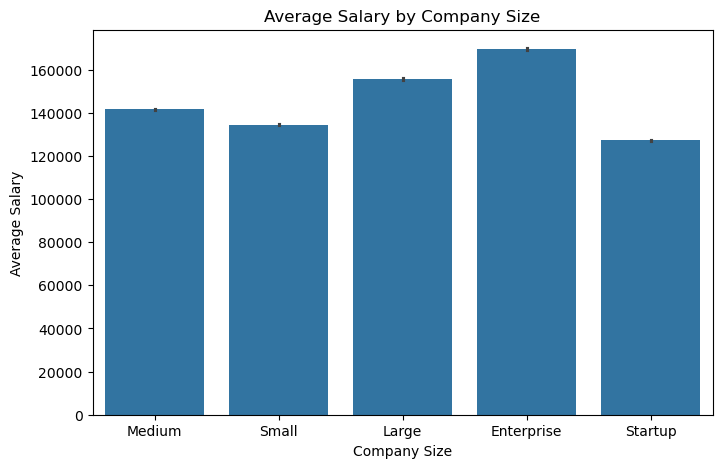

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(x='company_size', y='salary', data=df)

plt.title('Average Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Average Salary')

plt.show()

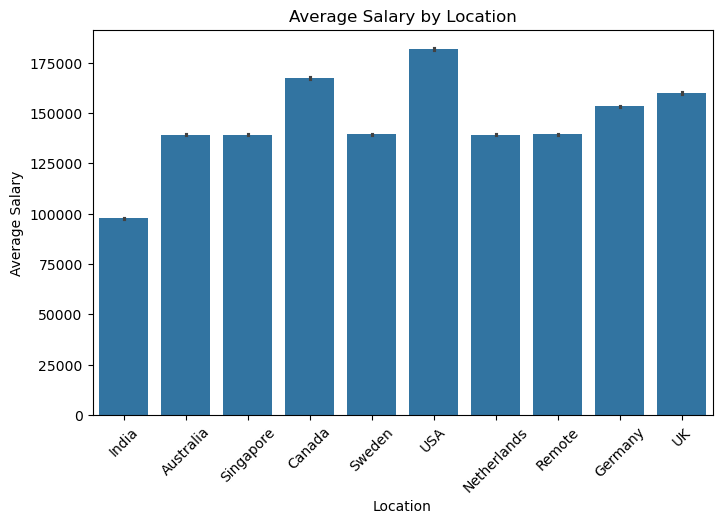

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(x='location', y='salary', data=df)

plt.title('Average Salary by Location')
plt.xlabel('Location')
plt.ylabel('Average Salary')

plt.xticks(rotation=45)
plt.show()

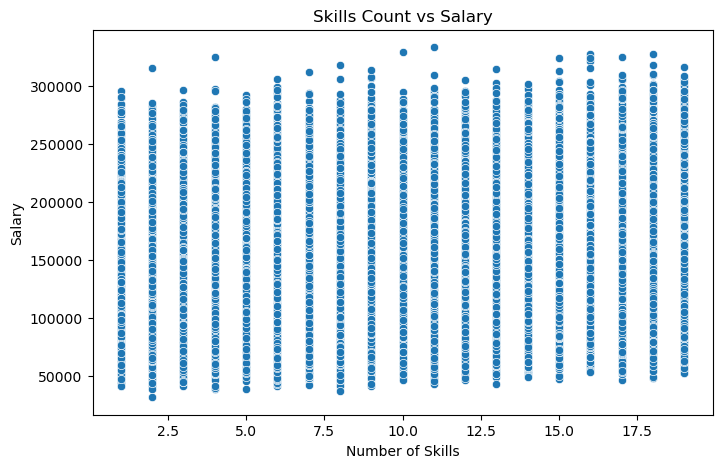

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='skills_count', y='salary', data=df)

plt.title('Skills Count vs Salary')
plt.xlabel('Number of Skills')
plt.ylabel('Salary')

plt.show()

In [35]:
corr = df.select_dtypes("number").drop(columns="salary").corr()
sns.heatmap(corr, annot=True);

# Split Data

#### Creating feature matrix X_train and target vector y_train

In [16]:
target = "salary"
y_train = df[target]
X_train = df.drop(columns="salary")

#### Separating the Training Data from the Testing Data

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

## Model Building

### Baseline

In [18]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
print("Mean salary price:", round(y_mean, 2))
print("Baseline MAE:", round(mean_absolute_error(y_train, y_pred_baseline), 2))

Mean salary price: 145713.97
Baseline MAE: 29807.72


### Iterate

In [33]:
model = make_pipeline(
    OneHotEncoder(),
    Ridge()
)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['job_title', 'education_level', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,False


## Evaluation

In [20]:
# Save Model as File
joblib.dump(model, "model.pkl")
# Load Model
model = joblib.load("model.pkl")

In [21]:
y_pred_training = model.predict(X_train)
print("Training MAE:", round(mean_absolute_error(y_train, y_pred_training), 2))

Training MAE: 5470.94


In [22]:
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    172848.655592
1     89236.805135
2     63795.199432
3    168309.961472
4    117223.476074
dtype: float64

In [23]:
test_mae = round(mean_absolute_error(y_test, y_pred_test), 2)
print("Test MAE: ", test_mae)

Test MAE:  5436.08


In [24]:
r2 = r2_score(y_test, y_pred_test)
print("R2 Score: ", round(r2, 2))

R2 Score:  0.96


## Communicate Results

In [25]:
feature_names = model.named_steps["onehotencoder"].get_feature_names()
feature_names[:5]

array(['job_title_1', 'job_title_2', 'job_title_3', 'job_title_4',
       'job_title_5'], dtype=object)

In [26]:
# intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 48
[ 17366.39707149  -6292.80920006 -25730.68849766 -23513.82437267
 -12859.81316682]


In [27]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

In [28]:
coef_df.head()

,feature,coefficient
0,job_title_1,17366.397071
1,job_title_2,-6292.809200
2,job_title_3,-25730.688498
3,job_title_4,-23513.824373
4,job_title_5,-12859.813167


In [29]:
top_positive = coef_df.sort_values(by="coefficient", ascending=False).head(10)
print(top_positive)

              feature   coefficient
42         location_9  35672.508905
5         job_title_6  28025.632227
33     company_size_5  24041.774981
36         location_3  21643.113180
14  education_level_2  18276.490615
0         job_title_1  17366.397071
37         location_4  14669.210596
8         job_title_9  11901.344911
30     company_size_2   9917.479169
38         location_5   7690.718342


In [30]:
top_negative = coef_df.sort_values(by="coefficient").head(10)
print(top_negative)

              feature   coefficient
34         location_1 -48149.292328
2         job_title_3 -25730.688498
3         job_title_4 -23513.824373
31     company_size_3 -18356.457774
15  education_level_3 -13991.668350
4         job_title_5 -12859.813167
32     company_size_4 -11364.278085
13  education_level_1  -8603.899387
35         location_2  -6339.056809
40         location_7  -6318.269349


### Let’s interpret the results properly

#### High positive coefficients (increase salary)
location_9 → very strong positive impact

job_title_6 → major salary driver

company_size_5 → larger firms likely pay more

location_3, location_4, location_5 → geography matters

education_level_2 → higher education increases salary

#### Strong negative coefficients (decrease salary)
location_1 → significantly lower salary region

job_title_3, job_title_4, job_title_5 → lower-paying roles

company_size_3, company_size_4 → mid/smaller firms pay less

education_level_3, education_level_1 → lower education impact


### Note
Categorical variables were pre-encoded, resulting in abstract feature names (e.g., job_title_1, location_3). While this limits direct interpretability, the relative importance and directional impact of these features remain valid.

### Core insights 

1. Location is the strongest driver
Huge variation (both positive and negative)
Suggests salary is highly geographically dependent

2. Job role matters significantly
Some roles strongly increase salary
Others significantly reduce it
Confirms role specialization effect

3. Company size influences pay
Larger companies → higher salaries, 
Smaller/mid firms → lower salaries

4. Education has a structured impact
Higher levels → positive effect, 
Lower levels → negative effect, 
But not as dominant as location or role

5. Salary is multi-factor driven

No single variable explains everything
Combination of:
location,
job role,
company size,
education

#### Creating a function "make_prediction" that takes Nine arguments () and returns your model's prediction for your Salary.

In [31]:
# Loading of trained pipeline
model = joblib.load("model.pkl") # saved model

def make_prediction(job_title, years_of_experience, education_level, skills_count, industry, company_size, location, certifications, remote_work):
    
    # Validation
    valid_remote = ["Remote", "Hybrid", "Onsite"]
    if remote_work not in valid_remote:
        raise ValueError(f"remote_work must be one of {valid_remote}")

    if years_of_experience < 0:
        raise ValueError("years_of_experience cannot be negative")

    input_data = {
        'job_title': job_title,
        'experience_years': years_of_experience,
        'education_level': education_level,
        'skills_count': skills_count,
        'industry': industry,
        'company_size': company_size,
        'location': location,
        'remote_work': remote_work,
        'certifications': certifications
    }

    df = pd.DataFrame(input_data, index=[0])
    prediction = model.predict(df).round(2)[0]

    return prediction


st.title("💰 Salary Prediction App")

st.write("Enter details below to predict salary")

# Inputs
job_title = st.text_input("Job Title", "AI Engineer")
experience = st.number_input("Years of Experience", min_value=0, value=5)
education = st.selectbox("Education Level", ["High School", "Bachelor", "Master", "PhD"])
skills = st.number_input("Number of Skills", min_value=0, value=3)
industry = st.text_input("Industry", "Tech")
company_size = st.selectbox("Company Size", ["Small", "Medium", "Large"])
location = st.text_input("Location", "USA")
remote_work = st.selectbox("Work Type", ["Remote", "Hybrid", "Onsite"])
certifications = st.number_input("Certifications", min_value=0, value=1)

# Prediction button
if st.button("Predict Salary"):
    
    input_data = {
        'job_title': job_title,
        'experience_years': experience,
        'education_level': education,
        'skills_count': skills,
        'industry': industry,
        'company_size': company_size,
        'location': location,
        'certifications': certifications,
        'remote_work': remote_work
        }

    df = pd.DataFrame(input_data, index=[0])

    try:
        prediction = make_prediction(
            job_title,
            experience,
            education,
            skills,
            industry,
            company_size,
            location,
            certifications,
            remote_work
        )
        
        st.success(f"Predicted Salary: ${prediction}")

    except Exception as e:
        st.error(str(e))

2026-04-22 08:24:59.561 
  command:

    streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-22 08:24:59.565 Session state does not function when running a script without `streamlit run`
